In [1]:
import pandas  as  pd 
import  numpy  as  np  
import matplotlib.pyplot  as  plt 
import   seaborn  as  sns 
import warnings
warnings.filterwarnings("ignore")
import re
import unicodedata
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from xgboost import XGBClassifier


In [2]:
df_row=pd.read_csv("FoodFacts.products.170k_May26.csv")
df_row.head()

,_id,product_name_en,ecoscore_grade,ingredients_text_en,categories,categories_hierarchy[0],categories_hierarchy[1],categories_hierarchy[2],categories_hierarchy[3],categories_hierarchy[4],...,packaging_hierarchy[43],packaging_hierarchy[44],packaging_hierarchy[45],packaging_hierarchy[46],packaging_hierarchy[47],packaging_hierarchy[48],packaging_hierarchy[49],packaging_hierarchy[50],packaging_hierarchy[51],packaging_hierarchy[52]
0,7896010000000.0,123,f,NaN,"Beverages and beverages preparations, Beverage...",en:beverages-and-beverages-preparations,en:plant-based-foods-and-beverages,en:beverages,en:plant-based-foods,en:beverage-preparations,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8410390000000.0,2022,e,NaN,"Dranken en drankbereidingen,Dranken,Alcoholisc...",en:beverages-and-beverages-preparations,en:beverages,en:alcoholic-beverages,en:wines,en:red-wines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8901060000000.0,5050,c,NaN,Biscuits,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4004200000000.0,5.00017E+12,c,NaN,Green tapenades,en:spreads,en:salted-spreads,en:tapenades,en:green-tapenades,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5203060000000.0,5.20306E+12,d,dog,Chocolate Cookie,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits-and-crackers,en:biscuits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_row["ingredients_text_en"].iloc[20
]

'Noodles: premium wheat flour, vegetable oil, salt (extra food salt, anti-caking agent E 536), gluten, premix stabilizer (stabilizers: E501i, E412, E452i), soy product (soy sauce powder, sugar, salt, yeast extract, fried onion). Broth-seasoning: broth base (chicken broth powder with vegetables, roasted red pepper, garlic, yeast extract, black pepper, flavoring, guar gum thickener), salt (extra food salt, anti-caking agent E 536), flavor and aroma enhancer ( E621), sugar, potato starch. Seasoning from dried vegetables: carrots, soy texture with chicken flavor (soy flour, soy sauce, sugar, glucose syrup, salt, flavoring), onion. Sauce: water, dry chicken extract, salt, sugar, vegetable oil, flavor and aroma enhancer (E621), preservatives (E211, E202), antioxidant (sodium isoascorbate).\\nThe product contains gluten, soy and traces of processed milk, fish, crustaceans and molluscs products.'

In [4]:
df_row["product_name_en"].sample(30)

154274                                    NaN
124920                                    NaN
38564                          Fruit & Crunch
126879                                    NaN
96801                   Spicy arrabiata sauce
121971                                    NaN
161410                                    NaN
101453                       Tangy Mayonnaise
63613                                Milk tea
29173        Dark chocolaty coated cookie pop
128504                                    NaN
93722              Sliced swiss cheese, swiss
165204                                    NaN
97668                          Stenfrie druer
15644                Caramel Protein Flapjack
20907                       Chocovlokken puur
126490                                    NaN
101506                             Tarama Dip
11619                        Boil-in-bag rice
37021                            Forest Honey
16043                       Casereccio salami
46365     Heinen's, cream cheese, 

In [5]:
df_row.columns

Index(['_id', 'product_name_en', 'ecoscore_grade', 'ingredients_text_en',
       'categories', 'categories_hierarchy[0]', 'categories_hierarchy[1]',
       'categories_hierarchy[2]', 'categories_hierarchy[3]',
       'categories_hierarchy[4]',
       ...
       'packaging_hierarchy[43]', 'packaging_hierarchy[44]',
       'packaging_hierarchy[45]', 'packaging_hierarchy[46]',
       'packaging_hierarchy[47]', 'packaging_hierarchy[48]',
       'packaging_hierarchy[49]', 'packaging_hierarchy[50]',
       'packaging_hierarchy[51]', 'packaging_hierarchy[52]'],
      dtype='object', length=509)

In [6]:
for prefix in [
    'ingredients_hierarchy',
    'categories_hierarchy',
    'origins_hierarchy',
    'packaging_hierarchy'
]:
    cols = [c for c in df_row.columns if prefix in c]

    non_null = df_row[cols].notnull().sum().sum()

    print(prefix)
    print("columns:", len(cols))
    print("total non-null:", non_null)
    print()

ingredients_hierarchy
columns: 365
total non-null: 2184291

categories_hierarchy
columns: 42
total non-null: 1045255

origins_hierarchy
columns: 14
total non-null: 16557

packaging_hierarchy
columns: 53
total non-null: 43111



In [7]:
df_row.shape

(171490, 509)

# step  1  create  columns  groups   

In [8]:
ingredient_cols = [
    c for c in df_row.columns
    if 'ingredients_hierarchy' in c]

category_cols = [
    c for c in df_row.columns
    if 'categories_hierarchy' in c]

#  step  2  merging columns   function  

In [9]:
def merge_hierarchy(row):

    values = []

    for item in row:

        if pd.notnull(item):

            # remove en:
            item = str(item).replace('en:', '')

            # replace hyphen with space
            item = item.replace('-', ' ')

            item = item.strip()

            if item:
                values.append(item)

    # remove duplicates while preserving order
    values = list(dict.fromkeys(values))

    return ' '.join(values)

# step 3  create  merged  smantic columns  

In [10]:
df_row['ingredient_hierarchy_text'] = (
    df_row[ingredient_cols]
    .apply(merge_hierarchy, axis=1))

df_row['category_hierarchy_text'] = (
    df_row[category_cols]
    .apply(merge_hierarchy, axis=1))

In [11]:
df_row['final_text'] = (
    df_row['ingredients_text_en'].fillna('') + ' ' +
    df_row['ingredient_hierarchy_text'].fillna('') + ' ' +
    df_row['category_hierarchy_text'].fillna(''))

In [12]:
df_row[["final_text", "ingredient_hierarchy_text", "category_hierarchy_text"]].head()


,final_text,ingredient_hierarchy_text,category_hierarchy_text
0,sugar added sugar disaccharide whole milk dai...,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...
1,beverages and beverages preparations beverag...,,beverages and beverages preparations beverages...
2,snacks sweet snacks biscuits and cakes biscuits,,snacks sweet snacks biscuits and cakes biscuits
3,spreads salted spreads tapenades green tapen...,,spreads salted spreads tapenades green tapenades
4,dog dog snacks sweet snacks biscuits and cakes...,dog,snacks sweet snacks biscuits and cakes biscuit...


In [13]:
df_row['final_text'].iloc[0]

' sugar added sugar disaccharide whole milk dairy milk maltodextrin whey powder whey instant coffee coffee pt:composto lacteo com gordura vegetal sabor de leite cocoa powder plant cocoa pt:aromatizantes acidity regulator pt:espessante carboximetilcelulose sodica e antiumectante fosfato tricalcico pt:alergicos e500ii e500 pt:contem derivados de leite soya lactose beverages and beverages preparations plant based foods and beverages beverages plant based foods beverage preparations coffees instant beverages coffee drinks instant coffees coffee with milk with sugar'

In [14]:
df_row.isnull().sum()

_id                               0
product_name_en               58008
ecoscore_grade                    0
ingredients_text_en           97165
categories                        5
                              ...  
packaging_hierarchy[51]      171489
packaging_hierarchy[52]      171489
ingredient_hierarchy_text         0
category_hierarchy_text           0
final_text                        0
Length: 512, dtype: int64

In [15]:
df_exp = df_row[[
    'ecoscore_grade',
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text','product_name_en',
    'final_text'
]].copy()

In [16]:
df_exp["ecoscore_grade"].value_counts()

ecoscore_grade
d         49480
b         34570
c         25989
e         24354
a         23288
f         10102
a-plus     3707
Name: count, dtype: int64

In [17]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
lemmatizer = WordNetLemmatizer()

In [19]:
def clean_final_text(text):

    if pd.isnull(text):
        return ""

    # lowercase
    text = text.lower()

    # unicode normalization
    text = unicodedata.normalize('NFKD', text)

    # remove language prefixes
    text = re.sub(r'\b[a-z]{2}:', ' ', text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove weird device metadata
    text = re.sub(r'galaxy\s\w+.*', ' ', text)

    # replace hyphens with spaces
    text = text.replace('-', ' ')

    # remove punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # remove isolated numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # lemmatization
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return ' '.join(words)

In [20]:
df_exp['clean_text'] = (
    df_exp['final_text']
    .apply(clean_final_text)
)

In [21]:
df_exp[['final_text', 'clean_text']].sample(5)

,final_text,clean_text
43299,"Prepared white beans, water, salt, disodium ed...",prepared white bean water salt disodium edta a...
87849,plant based foods and beverages plant based ...,plant based food and beverage plant based food...
49645,"milk, cream, sugars (sugar, glucose solids), m...",milk cream sugar sugar glucose solid modified ...
163261,fruit sugar added sugar disaccharide elder st...,fruit sugar added sugar disaccharide elder str...
131184,oat cereal honey added sugar peanut nut veget...,oat cereal honey added sugar peanut nut vegeta...


In [22]:
df_exp["clean_text"].iloc[0]

'sugar added sugar disaccharide whole milk dairy milk maltodextrin whey powder whey instant coffee coffee composto lacteo com gordura vegetal sabor de leite cocoa powder plant cocoa aromatizantes acidity regulator espessante carboximetilcelulose sodica e antiumectante fosfato tricalcico alergicos e500ii e500 contem derivados de leite soya lactose beverage and beverage preparation plant based food and beverage beverage plant based food beverage preparation coffee instant beverage coffee drink instant coffee coffee with milk with sugar'

In [23]:
df_row.shape

(171490, 512)

In [24]:
df_exp.shape

(171490, 7)

In [25]:
df_exp.columns

Index(['ecoscore_grade', 'ingredients_text_en', 'ingredient_hierarchy_text',
       'category_hierarchy_text', 'product_name_en', 'final_text',
       'clean_text'],
      dtype='object')

In [26]:
df_exp.isnull().sum()

ecoscore_grade                   0
ingredients_text_en          97165
ingredient_hierarchy_text        0
category_hierarchy_text          0
product_name_en              58008
final_text                       0
clean_text                       0
dtype: int64

In [27]:
df_exp["clean_text"].duplicated().sum()

np.int64(81171)

In [28]:
conflicts = (
    df_exp.groupby('clean_text')['ecoscore_grade']
    .nunique()
)

conflicts = conflicts[conflicts > 1]

print(len(conflicts))

2130


In [29]:
duplicate_counts = (
    df_exp['clean_text']
    .value_counts()
)

print(duplicate_counts.head(20))

clean_text
breakfast spread sweet spread bee product farming product sweetener honey                                                                              2389
plant based food and beverage beverage hot beverage plant based beverage tea                                                                           1489
dairy fermented food fermented milk product cheese                                                                                                     1468
snack sweet snack biscuit and cake biscuit                                                                                                             1456
snack sweet snack confectionery candy                                                                                                                  1430
plant based food and beverage plant based food breakfast cereal and potato cereal and their product breakfast cereal                                   1094
plant based food and beverage plant based food fat ve

In [30]:
df_exp.head()

,ecoscore_grade,ingredients_text_en,ingredient_hierarchy_text,category_hierarchy_text,product_name_en,final_text,clean_text
0,f,NaN,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...,123,sugar added sugar disaccharide whole milk dai...,sugar added sugar disaccharide whole milk dair...
1,e,NaN,,beverages and beverages preparations beverages...,2022,beverages and beverages preparations beverag...,beverage and beverage preparation beverage alc...
2,c,NaN,,snacks sweet snacks biscuits and cakes biscuits,5050,snacks sweet snacks biscuits and cakes biscuits,snack sweet snack biscuit and cake biscuit
3,c,NaN,,spreads salted spreads tapenades green tapenades,5.00017E+12,spreads salted spreads tapenades green tapen...,spread salted spread tapenade green tapenade
4,d,dog,dog,snacks sweet snacks biscuits and cakes biscuit...,5.20306E+12,dog dog snacks sweet snacks biscuits and cakes...,dog dog snack sweet snack biscuit and cake bis...


In [31]:
df_new = df_row[[
    'ecoscore_grade',
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text',
    'product_name_en'
]].copy()

In [32]:
df_new['clean_ingredients'] = (
    df_new['ingredients_text_en']
    .fillna('')
    .apply(clean_final_text)
)

df_new['clean_hierarchy'] = (
    df_new['ingredient_hierarchy_text']
    .fillna('')
    .apply(clean_final_text)
)

df_new['clean_category'] = (
    df_new['category_hierarchy_text']
    .fillna('')
    .apply(clean_final_text)
)

df_new['clean_product'] = (
    df_new['product_name_en']
    .fillna('')
    .apply(clean_final_text)
)

In [33]:
df_new['clean_product'] = df_new['clean_product'].replace(
    r'^\w{1,6}e$',
    '',
    regex=True
)

In [34]:
df_new = df_new[
    (
        df_new['clean_ingredients'].str.strip() != ''
    ) |
    (
        df_new['clean_hierarchy'].str.strip() != ''
    ) |
    (
        df_new['clean_product'].str.strip() != ''
    )
]

In [35]:
df_new.head()

,ecoscore_grade,ingredients_text_en,ingredient_hierarchy_text,category_hierarchy_text,product_name_en,clean_ingredients,clean_hierarchy,clean_category,clean_product
0,f,NaN,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...,123,,sugar added sugar disaccharide whole milk dair...,beverage and beverage preparation plant based ...,
4,d,dog,dog,snacks sweet snacks biscuits and cakes biscuit...,5.20306E+12,dog,dog,snack sweet snack biscuit and cake biscuit and...,
6,a,"GREEN ASPARAGUS (56%), Water. Salt, Acidity Re...",green asparagus vegetable shoot vegetable aspa...,plant based foods and beverages plant based fo...,Asparagus Spears,green asparagus water salt acidity regulator s...,green asparagus vegetable shoot vegetable aspa...,plant based food and beverage plant based food...,asparagus spear
7,a-plus,"Single cream (58%), Pasteurised Egg Yolk (12%)...",single cream dairy cream pasteurised egg yolk ...,dairies desserts dairy desserts creme brulee,Creme Brûlée,single cream pasteurised egg yolk sugar milk p...,single cream dairy cream pasteurised egg yolk ...,dairy dessert dairy dessert creme brulee,creme bru le e
8,a-plus,"Peach (50%), White Sugar, Brown Sugar, Concent...",peach fruit prunus species fruit white sugar a...,plant based foods and beverages plant based fo...,Peach Conserve,peach white sugar brown sugar concentrated lem...,peach fruit prunus specie fruit white sugar ad...,plant based food and beverage plant based food...,peach conserve


In [36]:
duplicate_cols = [
    'ecoscore_grade',
    'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product'
]

df_new = df_new.drop_duplicates(
    subset=duplicate_cols
)

In [37]:
df_new.head()

,ecoscore_grade,ingredients_text_en,ingredient_hierarchy_text,category_hierarchy_text,product_name_en,clean_ingredients,clean_hierarchy,clean_category,clean_product
0,f,NaN,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...,123,,sugar added sugar disaccharide whole milk dair...,beverage and beverage preparation plant based ...,
4,d,dog,dog,snacks sweet snacks biscuits and cakes biscuit...,5.20306E+12,dog,dog,snack sweet snack biscuit and cake biscuit and...,
6,a,"GREEN ASPARAGUS (56%), Water. Salt, Acidity Re...",green asparagus vegetable shoot vegetable aspa...,plant based foods and beverages plant based fo...,Asparagus Spears,green asparagus water salt acidity regulator s...,green asparagus vegetable shoot vegetable aspa...,plant based food and beverage plant based food...,asparagus spear
7,a-plus,"Single cream (58%), Pasteurised Egg Yolk (12%)...",single cream dairy cream pasteurised egg yolk ...,dairies desserts dairy desserts creme brulee,Creme Brûlée,single cream pasteurised egg yolk sugar milk p...,single cream dairy cream pasteurised egg yolk ...,dairy dessert dairy dessert creme brulee,creme bru le e
8,a-plus,"Peach (50%), White Sugar, Brown Sugar, Concent...",peach fruit prunus species fruit white sugar a...,plant based foods and beverages plant based fo...,Peach Conserve,peach white sugar brown sugar concentrated lem...,peach fruit prunus specie fruit white sugar ad...,plant based food and beverage plant based food...,peach conserve


In [38]:
df_new[[
    'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product'
]].sample(10)

,clean_ingredients,clean_hierarchy,clean_category,clean_product
89861,organic cane sugar organic enriched wheat flou...,cane sugar added sugar disaccharide sugar fort...,snack sweet snack biscuit and cake biscuit,sandwich cremes cooky
56074,,,dairy milk,leite sem lactose magro
94214,malted bread wheat flour calcium carbonate iro...,bread wheat flour cereal flour wheat cereal fl...,sandwich sandwich filled with cold cut cheese ...,smoked ham cheese on malted bread
91685,cheddar cheese cultured pasteurized milk salt ...,cheddar dairy cheese cultured pasteurized milk...,dairy fermented food fermented milk product ch...,sharp cheddar cheese with parmesan note
90435,cashew nut filtered water onion powder sea sal...,cashew nut nut tree nut filtered water water o...,dairy fermented food fermented milk product ch...,scallion french style soft cheese
794,extra virgin olive oil,extra virgin olive oil oil and fat vegetable o...,plant based food and beverage plant based food...,natural extra virgin olive oil
167299,sesame seed,sesame seed seed sesame,plant based food and beverage plant based food...,
32197,pasteurized whole milk skim milk culture enzym...,pasteurised whole milk dairy milk pasteurised ...,dairy fermented food fermented milk product ch...,eco meal feta cheese
24847,navy bean tomato sauce water reconstituted tom...,white bean vegetable legume pulse tomato sauce...,plant based food and beverage plant based food...,corale baked bean
123161,sugar blueberry concentrated lemon juice gelin...,sugar added sugar disaccharide blueberry fruit...,plant based food and beverage plant based food...,


In [39]:
df_new = df_new.drop(columns=[
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text',
    'product_name_en'
])

In [40]:
df_new.head()

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product
0,f,,sugar added sugar disaccharide whole milk dair...,beverage and beverage preparation plant based ...,
4,d,dog,dog,snack sweet snack biscuit and cake biscuit and...,
6,a,green asparagus water salt acidity regulator s...,green asparagus vegetable shoot vegetable aspa...,plant based food and beverage plant based food...,asparagus spear
7,a-plus,single cream pasteurised egg yolk sugar milk p...,single cream dairy cream pasteurised egg yolk ...,dairy dessert dairy dessert creme brulee,creme bru le e
8,a-plus,peach white sugar brown sugar concentrated lem...,peach fruit prunus specie fruit white sugar ad...,plant based food and beverage plant based food...,peach conserve


In [41]:
df_new.shape

(120239, 5)

In [42]:
df_new = df_new[
    (
        df_new['clean_ingredients'].str.strip() != ''
    ) |
    (
        df_new['clean_product'].str.strip() != ''
    )
]

In [43]:
df_new['ecoscore_grade'].value_counts()

ecoscore_grade
d         31415
b         19082
c         14180
a         12912
e         12473
f          5060
a-plus     1550
Name: count, dtype: int64

In [44]:
df_new.shape

(96672, 5)

In [45]:
duplicate_cols = [
    'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product',
    'ecoscore_grade'
]

duplicates = df_new.duplicated(
    subset=duplicate_cols
).sum()

print(duplicates)

0


In [46]:
df_new.sample(20)

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product
52935,c,whole grain oat semisweet chocolate chip cane ...,wholemeal oat cereal oat chocolate chunk choco...,snack sweet snack biscuit and cake biscuit,kashi cooky oatmeal dark chocolate 5oz
77786,e,,,plant based food and beverage plant based food...,peep breakfast cereal
90377,b,all natural honeybee honey,all natural honeybee honey,breakfast spread sweet spread bee product farm...,savannah bee company raw honey rosemary
24482,c,wheat flour m m s milk chocolate candy milk ch...,wheat flour cereal flour wheat cereal flour m ...,snack sweet snack biscuit and cake biscuit,cooky
7426,a,navy bean water sugar tomato paste thickener s...,white bean vegetable legume pulse water sugar ...,plant based food and beverage plant based food...,baked bean in tomato sauce
586,d,pasteurized goat milk salt starter culture mic...,pasteurised goat milk dairy milk goat milk sal...,dairy fermented food fermented milk product ch...,goat s milk goat cheese
31419,d,triple filtered purified water tomato white vi...,triple filtered purified water tomato vegetabl...,condiment sauce salad dressing grocery,dressing
112591,c,enriched flour wheat flour niacin reduced iron...,flour sugar added sugar disaccharide intereste...,snack sweet snack biscuit and cake biscuit waf...,woopee wafer vanilla
35842,b,,,snack salty snack popcorn salted popcorn,fiery hot cheese flavored popcorn
76500,a,tomato concentrated tomato pure e onion water ...,tomato vegetable fruit vegetable concentrated ...,condiment sauce tomato sauce tomato sauce with...,pasta sauce onion garlic


In [47]:
conflicts = (
    df_new.groupby([
        'clean_ingredients',
        'clean_hierarchy',
        'clean_category',
        'clean_product'
    ])['ecoscore_grade']
    .nunique()
)

conflicts = conflicts[conflicts > 1]

len(conflicts)

518

In [48]:
df_new['has_ingredients'] = (
    df_new['clean_ingredients'].str.strip() != ''
).astype(int)

df_new['has_product'] = (
    df_new['clean_product'].str.strip() != ''
).astype(int)

In [49]:
df_new.sample(20)

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product,has_ingredients,has_product
85450,d,base sour cream grade a cream non fat skim mil...,acidity regulator sour cream dairy cream micro...,dairy fermented food fermented milk product ch...,real food mexican cheddar dip,1,1
106634,b,tytteb r sukker vann fortykningsmiddel e440 su...,lingonberry fruit berry sugar added sugar disa...,plant based food and beverage plant based food...,tytteb rsyltet y 960g first price,1,1
50980,f,arborio rice,arborio rice rice rice from italy,plant based food and beverage plant based food...,italian arborio rice,1,1
1875,d,ultrafiltered milk water lactase vitamin d3,ultrafiltered milk water lactase enzyme cholec...,dairy milk,milk with protein,1,1
18927,a,,,plant based food and beverage plant based food...,chili ready diced tomato,0,1
67944,e,,,beverage and beverage preparation beverage dai...,nippy s iced chocolate flavoured milk,0,1
51635,b,cane sugar blackberry water fruit pectin citri...,cane sugar added sugar disaccharide sugar blac...,plant based food and beverage plant based food...,jam,1,1
105637,d,pasteurized milk cream mushroom natural flavor...,pasteurised milk dairy milk cream mushroom nat...,dairy fermented food fermented milk product ch...,triple cream soft ripened cheese with mushroom,1,1
86289,a,olive water minced pimiento water pimiento sod...,olive vegetable fruit vegetable water pimiento...,plant based food and beverage beverage hot bev...,reduced sodium pimento stuffed manzanilla olive,1,1
89317,e,pasteurized cream salt culture,cream dairy salt microbial culture ferment,dairy fat spread spreadable fat animal fat dai...,salted butter,1,1


In [50]:
df_new['additive_count'] = (
    df_row.loc[df_new.index, 'ingredients_text_en']
    .fillna('')
    .str.lower()
    .str.count(r'e\s?\d+[a-z]*')
)

In [51]:
additive_keywords = [
    'preservative',
    'stabilizer',
    'emulsifier',
    'flavour enhancer',
    'flavor enhancer',
    'thickener',
    'acidity regulator',
    'antioxidant',
    'colour',
    'coloring',
    'sweetener'
]

pattern = '|'.join(additive_keywords)

df_new['additive_keyword_count'] = (
    df_row.loc[df_new.index, 'ingredients_text_en']
    .fillna('')
    .str.lower()
    .str.count(pattern)
)

In [52]:
df_new['total_additive_signal'] = (
    df_new['additive_count'] +
    df_new['additive_keyword_count']
)

In [53]:
df_new['ingredient_length'] = (
    df_new['clean_ingredients']
    .apply(lambda x: len(x.split()))
)

df_new['product_length'] = (
    df_new['clean_product']
    .apply(lambda x: len(x.split()))
)

In [54]:
df_new.sample(20)

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product,has_ingredients,has_product,additive_count,additive_keyword_count,total_additive_signal,ingredient_length,product_length
99620,c,raw sunflower seed kernel,sunflower seed plant seed sunflower,plant based food and beverage plant based food...,sunflower seed,1,1,0,0,0,4,2
151744,d,milk salt starter culture vegetarian rennet,milk dairy salt microbial culture ferment renn...,dairy fermented food fermented milk product ch...,,1,0,0,0,0,6,0
29604,d,flour enriched wheat flour malted barley flour...,flour butter blend margarine granulated sugar ...,snack sweet snack biscuit and cake biscuit,decorated cookie company gourmet decorated sho...,1,1,2,3,5,75,7
102223,d,,,snack sweet snack confectionery candy,tetes bruler coffret,0,1,0,0,0,0,3
59352,c,,water vegetable oil oil and fat vegetable oil ...,plant based food and beverage plant based food...,magra,0,1,0,0,0,0,1
123079,e,salt parsley garlic shallot pepper rapeseed oi...,salt parsley vegetable herb leaf vegetable gar...,plant based food and beverage plant based food...,,1,0,0,0,0,9,0
95951,b,,,breakfast spread sweet spread bee product farm...,southern alp honey dew honey,0,1,0,0,0,0,5
84117,c,,courgette vegetable fruit vegetable water onio...,plant based food and beverage plant based food...,quinoa mix zucchini onion,0,1,0,0,0,0,4
74397,d,certified organic grade a milk refined fish oi...,grade a milk fish oil oil and fat oil cholecal...,dairy milk whole milk,organic whole milk,1,1,0,0,0,10,3
40123,d,skimmed milk milk protein thickener cellulose ...,skimmed milk dairy milk milk protein protein a...,beverage and beverage preparation beverage dai...,getpro vanilla protein drink,1,1,0,2,2,18,4


In [55]:
df_new["total_additive_signal"].value_counts()

total_additive_signal
0     77012
1     10901
2      4006
3      1900
4      1065
5       556
6       360
7       262
8       194
9       107
10       67
11       47
12       47
13       32
14       25
15       18
17       14
16       11
23        8
18        7
19        7
20        5
21        5
29        4
22        3
27        2
31        1
73        1
34        1
26        1
39        1
66        1
37        1
Name: count, dtype: int64

In [56]:
df_new[df_new['total_additive_signal'] > 25][[
    'clean_ingredients',
    'total_additive_signal',"ecoscore_grade"
]].head(10)

,clean_ingredients,total_additive_signal,ecoscore_grade
6611,milk butter from milk watermelon filling sugar...,29,b
14154,sucre sirop de glucose huile de noix de coco a...,31,d
14334,chocolate liquid glucose cocoa solid paim oil ...,29,b
20935,frozen dessert ingredient water compound coati...,27,b
22664,ring pack ingredient cocoa strawberry star whe...,73,c
27215,pork product quot pork stuffing quot pork prod...,27,e
30958,donut cocoa wheat flour water palm oil sugar m...,29,c
52104,strawberry water sugar fructose thickener e407...,34,b
59340,reconstituted skimmed milk sweeten maltitol er...,26,b
83743,pork product quot ham stuffing quot ham pork m...,29,e


In [57]:
df_new.groupby('ecoscore_grade')[
    'total_additive_signal'
].mean().sort_values()

ecoscore_grade
a         0.278423
f         0.323913
a-plus    0.336129
e         0.351319
b         0.451001
d         0.505459
c         0.559309
Name: total_additive_signal, dtype: float64

<Axes: xlabel='ecoscore_grade'>

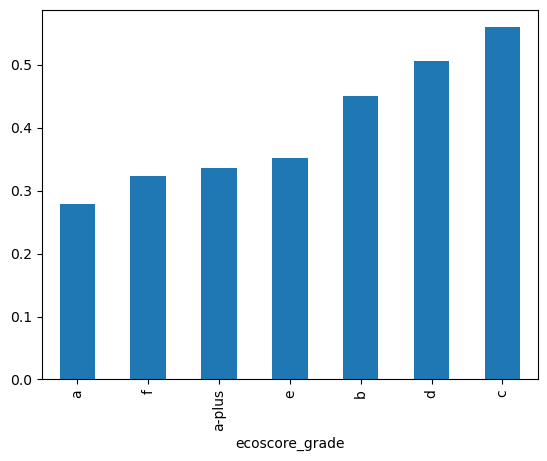

In [58]:
df_new.groupby('ecoscore_grade')['total_additive_signal'].mean().sort_values().plot(kind='bar')


In [59]:
df_new['additives_text'] = (
    df_row.loc[df_new.index, 'ingredients_text_en']
    .fillna('')
    .str.lower()
    .str.findall(r'e[\s\-]?\d{3}[a-z]*')
    .apply(lambda x: ' '.join(x))
)

In [60]:
df_new['additives_text'].value_counts()

additives_text
                                   93926
e471                                  70
e476                                  51
e 100                                 51
e330                                  46
                                   ...  
e331 e339 e452 e202 e160c e160a        1
e450 e500 e450 e500                    1
e 650ge                                1
e461 e407                              1
e211 e202 e211 e202                    1
Name: count, Length: 1732, dtype: int64

In [61]:
df_new['additives_text'] = (
    df_new['additives_text']
    .str.replace(r'e\s+(\d{3}[a-z]{0,2})', r'e\1', regex=True)
)

In [62]:
df_new['additives_text'].value_counts()

additives_text
                                   93926
e471                                  73
e330                                  58
e100                                  57
e476                                  56
                                   ...  
e331 e339 e452 e202 e160c e160a        1
e450 e500 e450 e500                    1
e650ge                                 1
e461 e407                              1
e211 e202 e211 e202                    1
Name: count, Length: 1636, dtype: int64

In [63]:
label_order = [
    'a-plus',
    'a',
    'b',
    'c',
    'd',
    'e',
    'f'
]

le = LabelEncoder()

le.fit(label_order)

y = le.transform(df_new['ecoscore_grade'])

In [64]:
text_features = [
    'clean_hierarchy',
    'clean_category'
]

In [65]:
text_features = [
     'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product',
     
]

"""numeric_features = [
    'has_ingredients',
    'has_product',
    'ingredient_length',
    'product_length',
    'additive_count',
    'additive_keyword_count',
    'total_additive_signal'
]"""

"numeric_features = [\n    'has_ingredients',\n    'has_product',\n    'ingredient_length',\n    'product_length',\n    'additive_count',\n    'additive_keyword_count',\n    'total_additive_signal'\n]"

In [66]:
X = df_new[text_features ]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(77337, 4)
(19335, 4)


In [67]:
ingredient_tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

In [68]:
hierarchy_tfidf = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [69]:
category_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [70]:
product_tfidf = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [71]:
additive_tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    min_df=2
)

 (
            'hierarchy_tfidf',
            hierarchy_tfidf,
            'clean_hierarchy'
        ),

        (
            'category_tfidf',
            category_tfidf,
            'clean_category'
        ),
 (
            'additive_tfidf',
            additive_tfidf,
            'additives_text'
        )
       

  """(
            'ingredients_tfidf',
            ingredient_tfidf,
            'clean_ingredients'
        )"""

        (
            'hierarchy_tfidf',
            hierarchy_tfidf,
            'clean_hierarchy'
        ),

        """(
            'category_tfidf',
            category_tfidf,
            'clean_category'
        ),""",

        (
            'product_tfidf',
            product_tfidf,
            'clean_product'
        ),

        """(
            'additive_tfidf',
            additive_tfidf,
            'additives_text'
        )"""
       


In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ingredients_tfidf', ingredient_tfidf, 'clean_ingredients'),
        ('hierarchy_tfidf', hierarchy_tfidf, 'clean_hierarchy'),
        ('category_tfidf', category_tfidf, 'clean_category'),
        ('product_tfidf', product_tfidf, 'clean_product'),
    ]
)

In [73]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)

In [74]:
X_test_transformed = preprocessor.transform(
    X_test
)

In [75]:
print(X_train_transformed.shape)

print(X_test_transformed.shape)

(77337, 25000)
(19335, 25000)


In [76]:
xgb_model = XGBClassifier(

    objective='multi:softmax',

    num_class=7,

    n_estimators=150,

    learning_rate=0.08,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='mlogloss',

    random_state=42,  n_jobs=-1
)

In [78]:
xgb_model.fit(
    X_train_transformed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1, num_class=7, ...)

In [79]:
y_pred = xgb_model.predict(
    X_test_transformed
)

In [80]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.8688388931988622


In [81]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

           a       0.87      0.83      0.85      2582
      a-plus       0.55      0.09      0.16       310
           b       0.86      0.89      0.88      3817
           c       0.86      0.78      0.82      2836
           d       0.90      0.92      0.91      6283
           e       0.81      0.92      0.86      2495
           f       0.86      0.93      0.89      1012

    accuracy                           0.87     19335
   macro avg       0.82      0.77      0.77     19335
weighted avg       0.87      0.87      0.86     19335



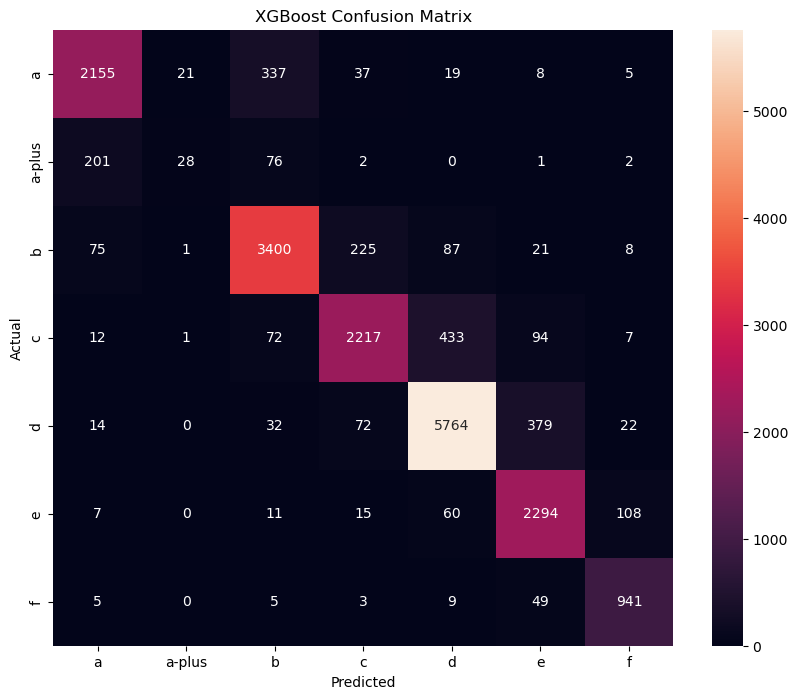

In [82]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [83]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(
    alpha=0.5
)

nb_model.fit(
    X_train_transformed,
    y_train
)

MultinomialNB(alpha=0.5)

In [84]:
y_pred = nb_model.predict(
    X_test_transformed
)

In [85]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)hould we 

print("Accuracy:", accuracy)

SyntaxError: invalid syntax (2580740364.py, line 6)

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

In [ ]:
df_new.loc[0:5].head()